In [1]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Set parameters and load data
data_dir = "dataset"
img = plt.imread(f"{data_dir}/happy/265.jpg")
img_size = img.shape
epochs = 20
seed = 123
batch_size = 64
tf.random.set_seed(seed)

# Load training and validation data
train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size[:2],
    batch_size=batch_size
)

val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size[:2],
    batch_size=batch_size
)

# Get class names
class_names = train_data.class_names
print("Class names:", class_names)

# Normalise pixel values
normalization_layer = layers.Rescaling(1./255)
train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

# Build the model
model = models.Sequential([
    layers.Input(shape=(48, 48, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(3, activation='softmax')
    
    ])

# Compile and train the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
)

# Save the model
model_name = "Simple_model_1.h5"
model.save(model_name)

Found 16095 files belonging to 3 classes.
Using 12876 files for training.
Found 16095 files belonging to 3 classes.
Using 3219 files for validation.
Class names: ['angry', 'happy', 'sad']
Epoch 1/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 52s 254ms/step - accuracy: 0.4923 - loss: 1.0203 - val_accuracy: 0.5648 - val_loss: 0.9420
Epoch 2/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.5774 - loss: 0.9086 - val_accuracy: 0.5722 - val_loss: 0.9070
Epoch 3/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6141 - loss: 0.8473 - val_accuracy: 0.6145 - val_loss: 0.8472
Epoch 4/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6347 - loss: 0.8091 - val_accuracy: 0.6344 - val_loss: 0.8171
Epoch 5/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.6510 - loss: 0.7769 - val_accuracy: 0.6424 - val_loss: 0.8082
Epoch 6/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6693 - loss: 0.7507 - val_accuracy: 0.6542 - val_loss: 0.7847
Epoch 7/15
202/202 ━━━━━━━━━━━━━━━━━

Found 16095 files belonging to 3 classes.
Using 3219 files for validation.
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6477 - loss: 111.9635
Validation Loss: 111.96348571777344
Validation Accuracy: 0.6477167010307312
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━

<Figure size 640x480 with 0 Axes>

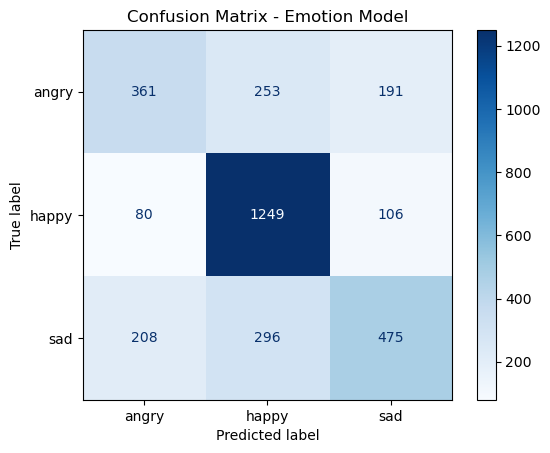

In [5]:
# Load 
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

data_dir = "dataset"
model = models.load_model("Simple_model_1.h5")
val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(48,48),
    batch_size=64
)

# Evaluation
loss, acc = model.evaluate(val_data)
print("Validation Loss:", loss)
print("Validation Accuracy:", acc)

# Predictions
class_names = val_data.class_names
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure()
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Emotion Model")
plt.show()